Step 1: Dataset Description

In [ ]:
!pip install tensorflow scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 119.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 126.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.6 MB/s eta 0:00:00


In [ ]:

import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling & Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, learning_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Models
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neural_network import MLPClassifier, MLPRegressor

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, roc_auc_score, classification_report,
    r2_score, mean_absolute_error, mean_squared_error
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

#DATA_PATH = "/content/drive/MyDrive/project_cs422/Tree_Sterility_Dataset - Tree_Sterility_Dataset (1).csv"   # <-- change if needed

file_link = "https://drive.google.com/file/d/1JlZPLy4ad6eT5Vh4kFgwZ9Q9tplu1m7f/view"
id = file_link.split('/')[-2]
# print(id)

DATA_PATH = f"https://drive.google.com/uc?id={id}"  # link modified to make dataset downloadable
print(DATA_PATH)


https://drive.google.com/uc?id=1JlZPLy4ad6eT5Vh4kFgwZ9Q9tplu1m7f


Load Data & Quick Peek

In [ ]:
# Load Data & Quick Peek
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values (count):")
display(df.isna().sum())


Shape: (2783, 24)
Columns: ['No', 'Plot', 'Subplot', 'Species', 'Light_ISF', 'Light_Cat', 'Core', 'Soil', 'Adult', 'Sterile', 'Conspecific', 'Myco', 'SoilMyco', 'PlantDate', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Census', 'Time', 'Event', 'Harvest', 'Alive']


,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,...,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
0,126,1,C,Acer saccharum,0.106,Med,2017,Prunus serotina,I,Non-Sterile,...,22.00,NaN,-0.56,13.86,12.15,4,14.0,1.0,NaN,NaN
1,11,1,C,Quercus alba,0.106,Med,2017,Quercus rubra,970,Non-Sterile,...,15.82,31.07,5.19,20.52,19.29,33,115.5,0.0,NaN,X
2,12,1,C,Quercus rubra,0.106,Med,2017,Prunus serotina,J,Non-Sterile,...,24.45,28.19,3.36,24.74,15.01,18,63.0,1.0,NaN,NaN
3,2823,7,D,Acer saccharum,0.080,Med,2016,Prunus serotina,J,Non-Sterile,...,22.23,NaN,-0.71,14.29,12.36,4,14.0,1.0,NaN,NaN
4,5679,14,A,Acer saccharum,0.060,Low,2017,Prunus serotina,689,Non-Sterile,...,21.15,NaN,-0.58,10.85,11.20,4,14.0,1.0,NaN,NaN



Data Types:


,0
No,int64
Plot,int64
Subplot,object
Species,object
Light_ISF,float64
Light_Cat,object
Core,int64
Soil,object
Adult,object
Sterile,object



Missing Values (count):


,0
No,0
Plot,0
Subplot,0
Species,0
Light_ISF,0
Light_Cat,0
Core,0
Soil,0
Adult,0
Sterile,0


Target Selection & Problem Type

In [ ]:
#  Target Selection & Problem Type
TARGET_COL = None  # e.g., set to "Sterility" if you know it. Leave None to auto-guess.

def guess_target_column(dataframe):
    candidates = ["sterility","target","label","class","outcome","y"]
    cols_lower = {c.lower(): c for c in dataframe.columns}
    for key in candidates:
        if key in cols_lower:
            return cols_lower[key]
    # heuristic: low-cardinality column, avoid id-like
    n = len(dataframe)
    low_card_cols = [c for c in dataframe.columns
                     if dataframe[c].nunique() <= max(20, int(0.05*n))]
    low_card_cols = [c for c in low_card_cols
                     if not any(k in c.lower() for k in ["id","idx","index"])]
    if low_card_cols:
        return dataframe.columns[-1] if dataframe.columns[-1] in low_card_cols else low_card_cols[-1]
    return dataframe.columns[-1]

if TARGET_COL is None:
    TARGET_COL = guess_target_column(df)

print(f"Using target column: {TARGET_COL!r}")

y_raw = df[TARGET_COL]
X_raw = df.drop(columns=[TARGET_COL])

def infer_problem_type(y):
    if y.dtype == 'O' or str(y.dtype).startswith('bool'):
        return "classification"
    if pd.api.types.is_numeric_dtype(y) and y.nunique() <= max(20, int(0.05*len(y))):
        return "classification"
    return "regression"

PROBLEM_TYPE = infer_problem_type(y_raw)
print("Inferred problem type:", PROBLEM_TYPE.upper())


Using target column: 'Alive'
Inferred problem type: CLASSIFICATION


Descriptive Analysis & Summary Statistics

In [ ]:
# ===== Cell 4: Descriptive Analysis & Summary Stats =====
numeric_features = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric features ({len(numeric_features)}):", numeric_features)
print(f"Categorical features ({len(categorical_features)}):", categorical_features)

# Summary statistics (Numerical) + Variance
if numeric_features:
    num_summary = X_raw[numeric_features].describe().T
    num_summary["variance"] = X_raw[numeric_features].var()
    display(num_summary)

# Summary statistics (Categorical)
if categorical_features:
    cat_summary = []
    for c in categorical_features:
        vc = X_raw[c].value_counts(dropna=False)
        top = vc.index[0] if len(vc) else None
        freq = vc.iloc[0] if len(vc) else None
        cat_summary.append({
            "feature": c,
            "n_unique": X_raw[c].nunique(dropna=True),
            "top": top,
            "top_freq": freq
        })
    display(pd.DataFrame(cat_summary))

# Class balance (if classification)
if PROBLEM_TYPE == "classification":
    print("\nClass distribution of target:")
    display(y_raw.value_counts(dropna=False))


Numeric features (12): ['No', 'Plot', 'Light_ISF', 'Core', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Census', 'Time', 'Event']
Categorical features (11): ['Subplot', 'Species', 'Light_Cat', 'Soil', 'Adult', 'Sterile', 'Conspecific', 'Myco', 'SoilMyco', 'PlantDate', 'Harvest']


,count,mean,std,min,25%,50%,75%,max,variance
No,2783.0,3914.513834,2253.515063,3.000,1971.000,3932.000,5879.000,7772.000,5.078330e+06
Plot,2783.0,9.561624,5.203659,1.000,5.000,10.000,14.000,18.000,2.707807e+01
Light_ISF,2783.0,0.085707,0.025638,0.032,0.066,0.082,0.100,0.161,6.572914e-04
Core,2783.0,2016.648940,0.477387,2016.000,2016.000,2017.000,2017.000,2017.000,2.278988e-01
AMF,2783.0,20.553069,12.309587,0.000,13.400,18.000,24.445,100.000,1.515259e+02
EMF,1283.0,26.476750,16.636890,0.000,13.780,27.720,35.710,87.500,2.767861e+02
Phenolics,2783.0,1.933105,1.969842,-1.350,0.170,0.750,3.780,6.100,3.880277e+00
Lignin,2783.0,15.759792,6.779607,2.230,10.355,14.040,21.115,32.770,4.596307e+01
NSC,2783.0,14.219641,4.298271,4.300,11.605,12.660,17.275,29.450,1.847513e+01
Census,2783.0,15.282070,9.166555,4.000,7.000,13.000,18.000,33.000,8.402573e+01


,feature,n_unique,top,top_freq
0,Subplot,5,A,701
1,Species,4,Acer saccharum,751
2,Light_Cat,3,Med,1474
3,Soil,7,Sterile,423
4,Adult,36,I,90
5,Sterile,2,Non-Sterile,2360
6,Conspecific,3,Heterospecific,1974
7,Myco,2,AMF,1500
8,SoilMyco,3,AMF,1186
9,PlantDate,19,6/7/18,340



Class distribution of target:


,count
Alive,
NaN,2292
X,491


 EDA Plots: Histograms, Box Plots, Density (KDE), Correlation Heatmap

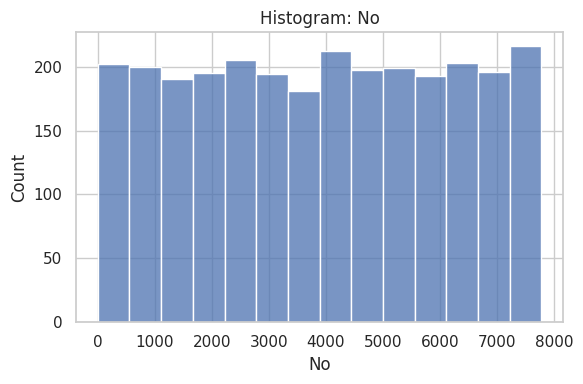

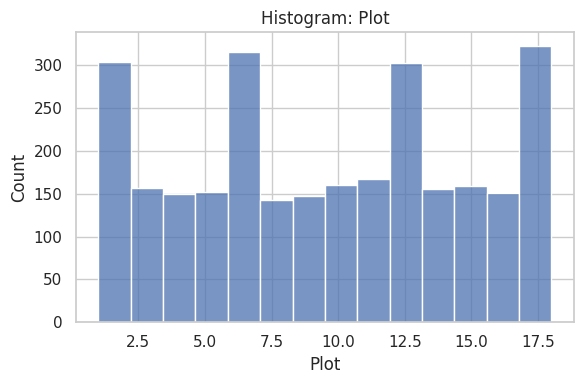

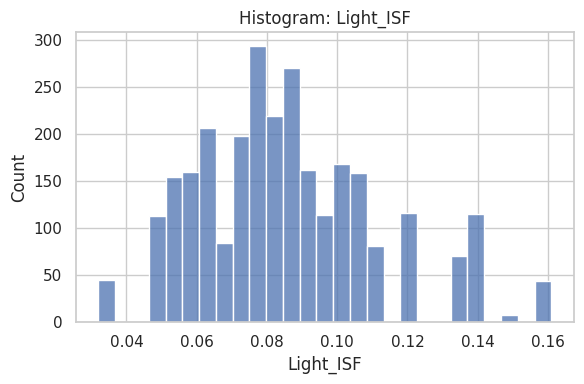

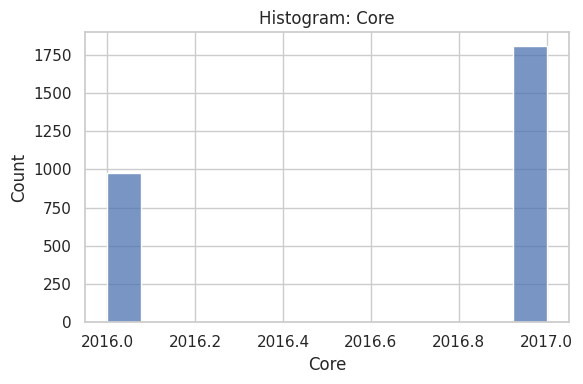

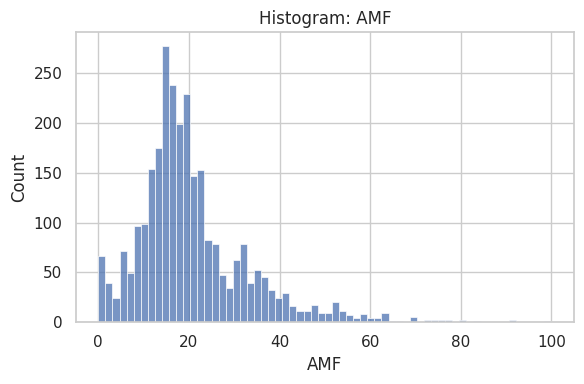

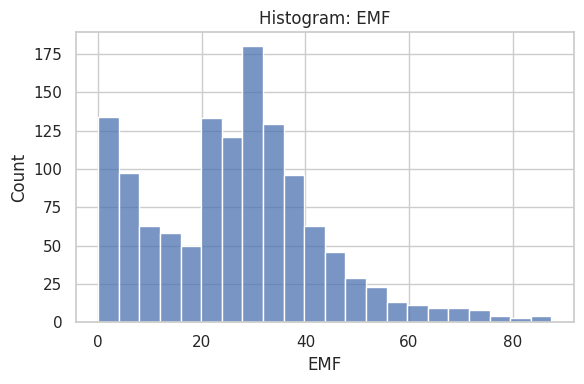

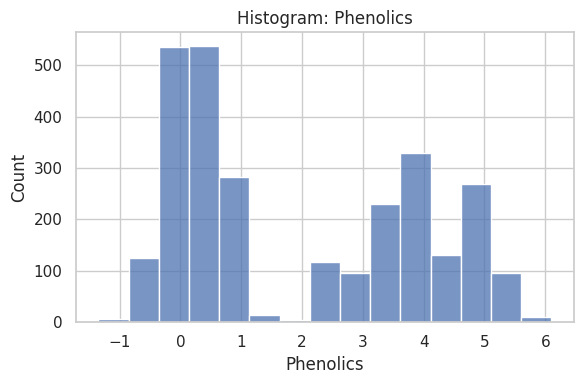

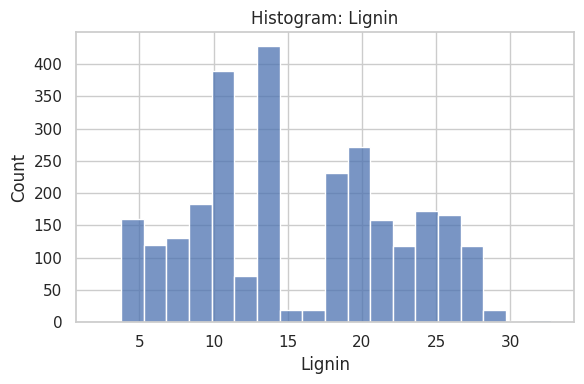

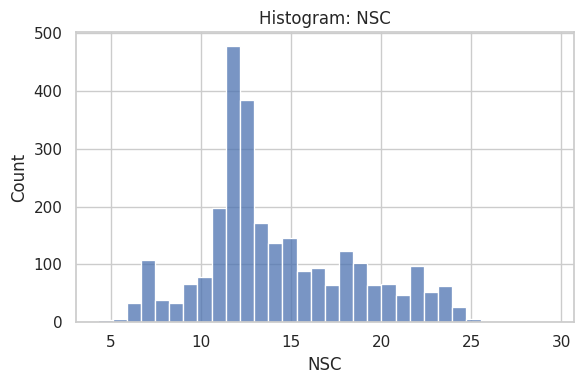

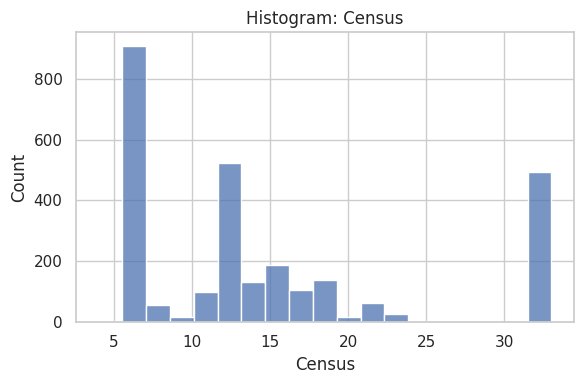

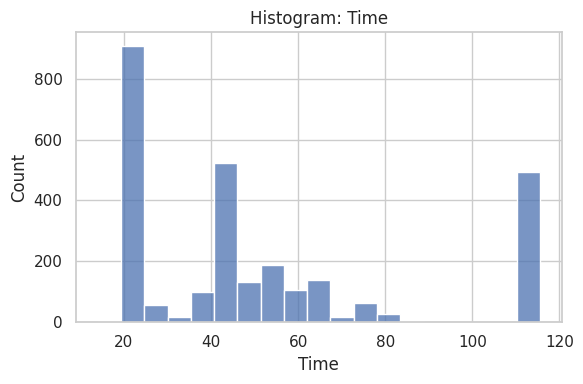

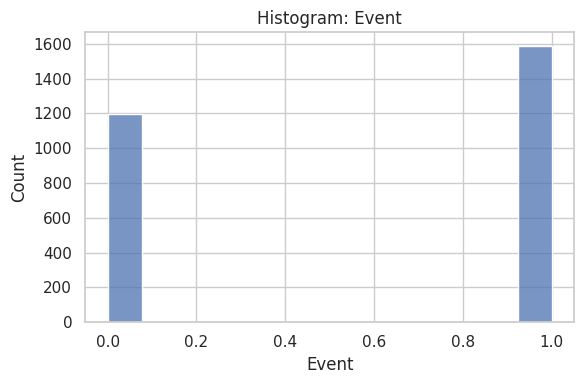

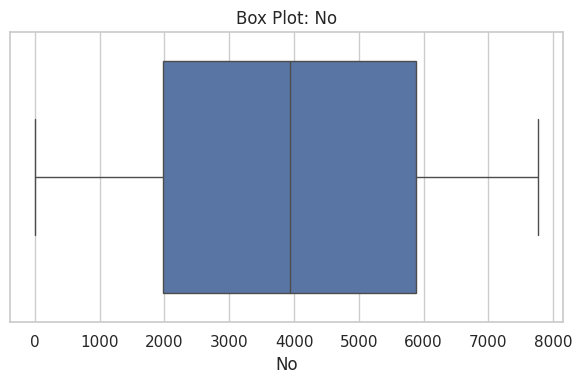

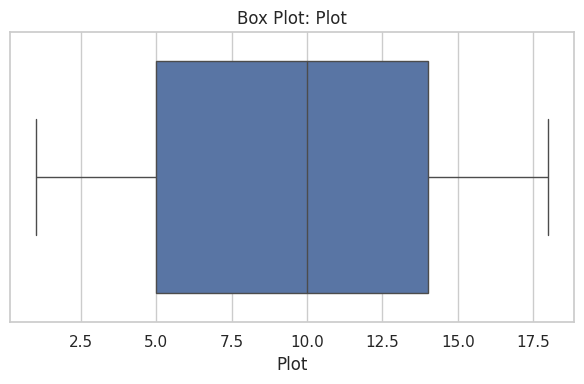

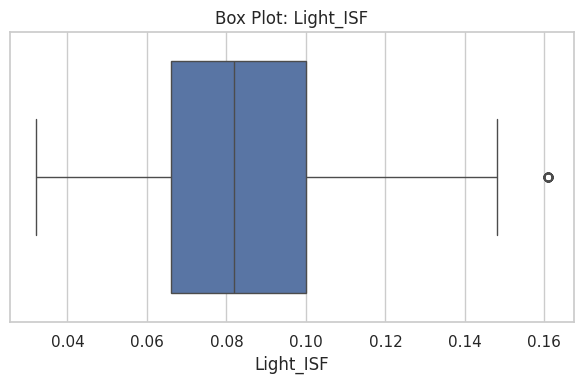

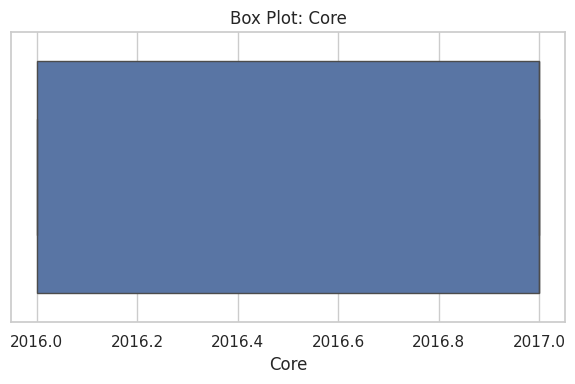

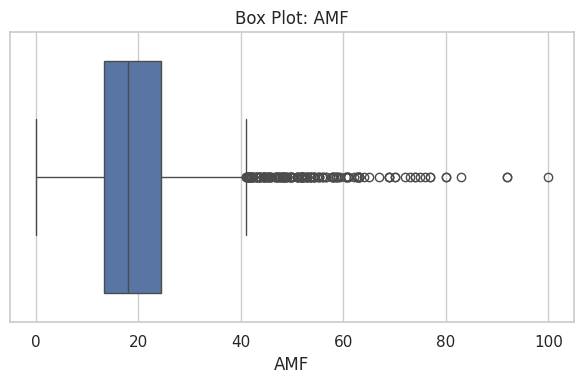

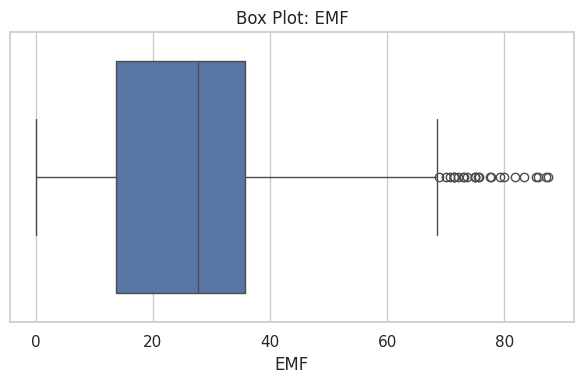

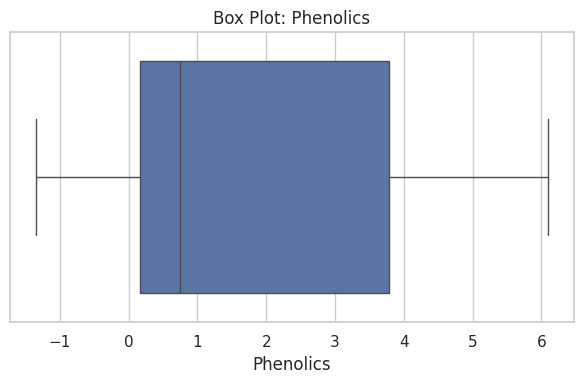

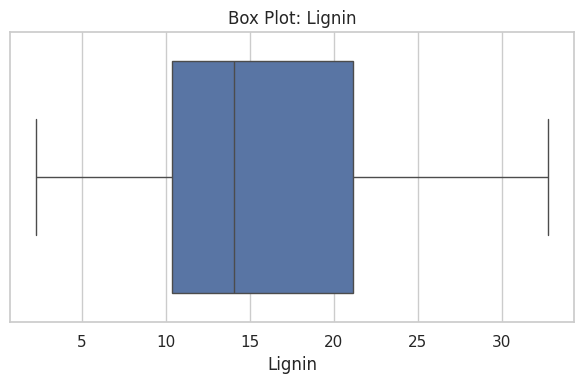

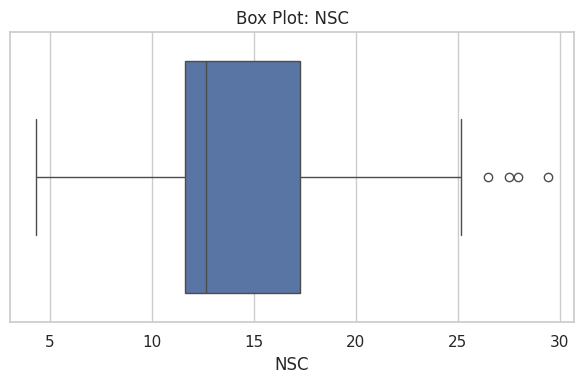

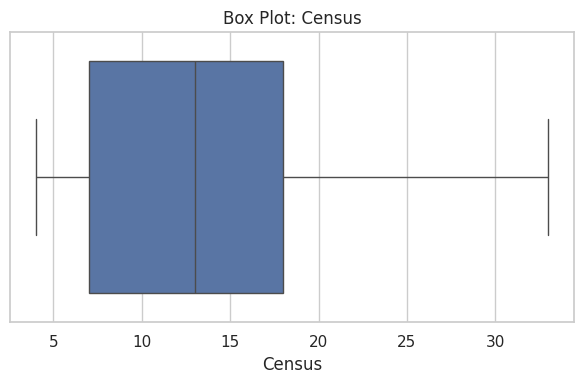

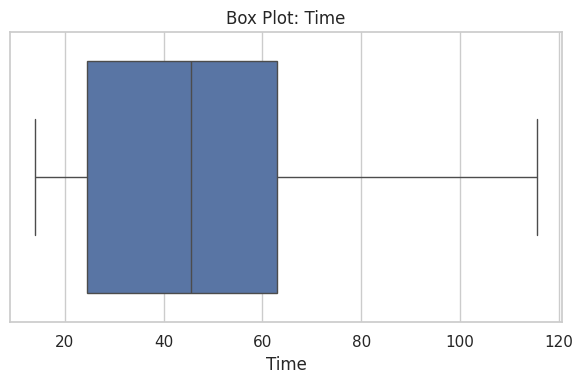

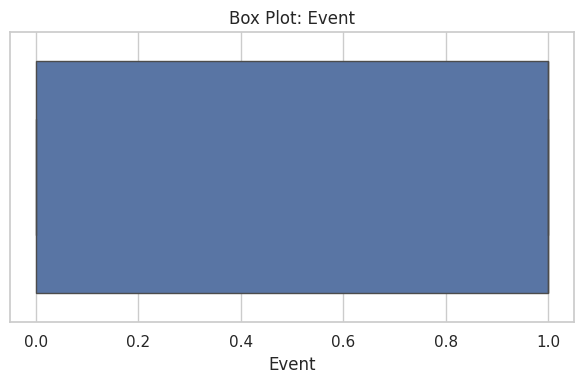

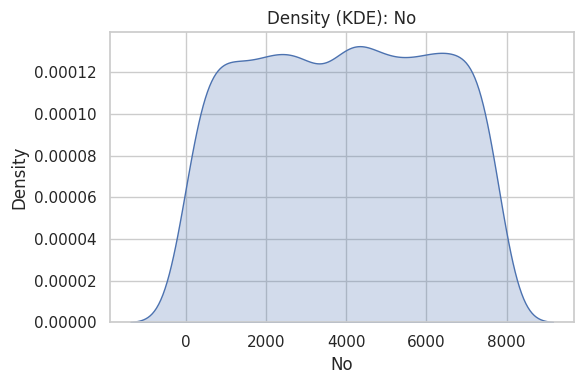

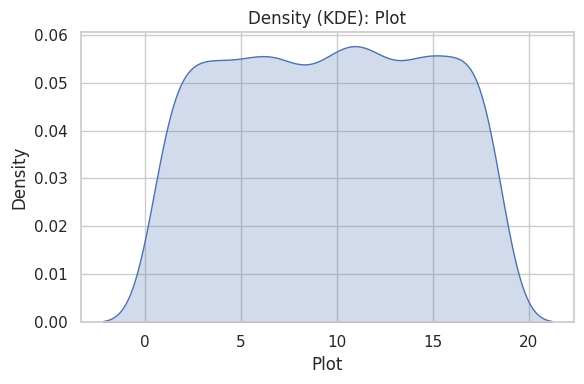

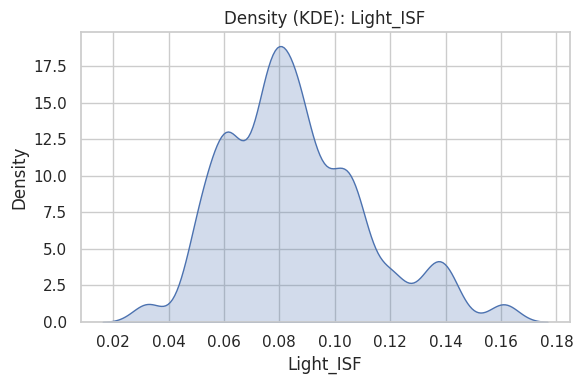

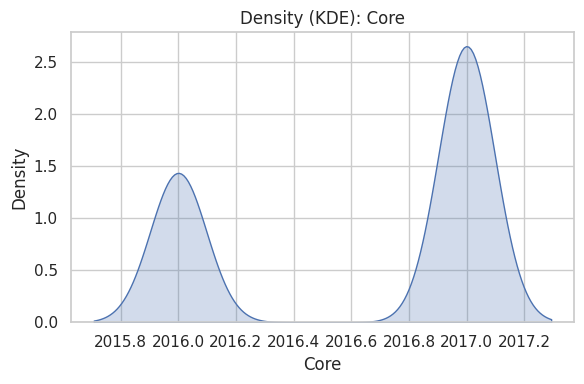

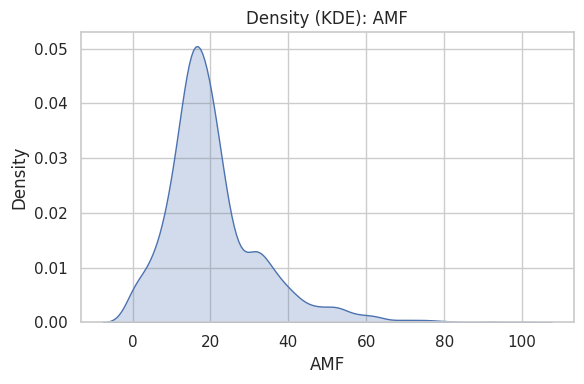

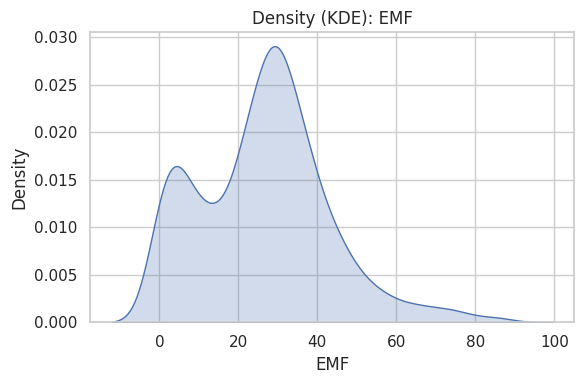

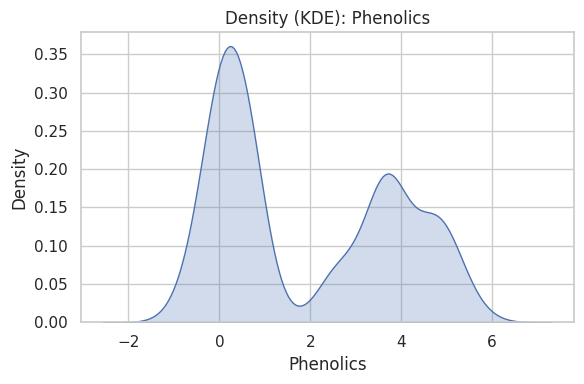

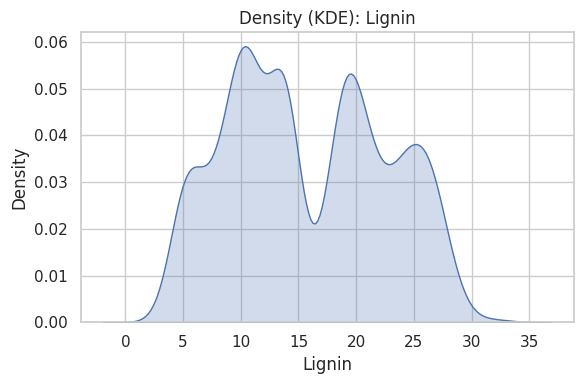

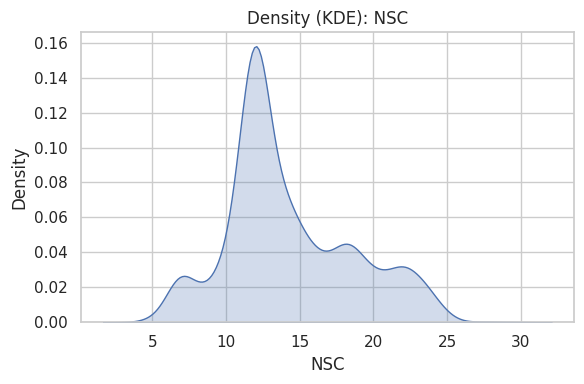

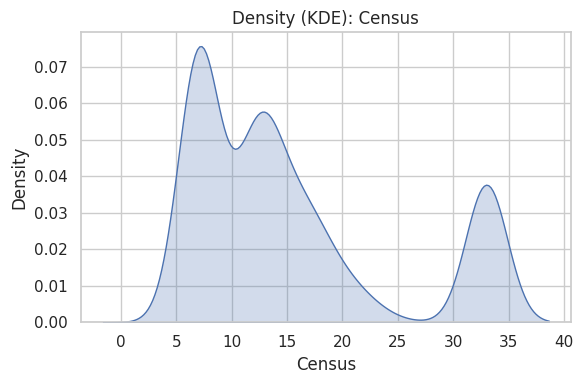

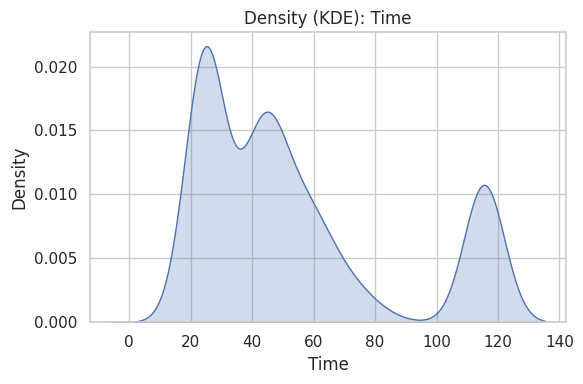

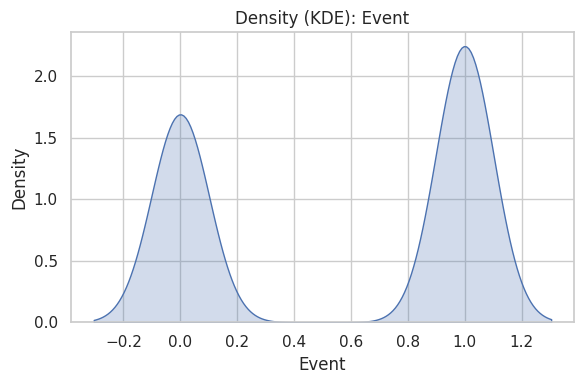

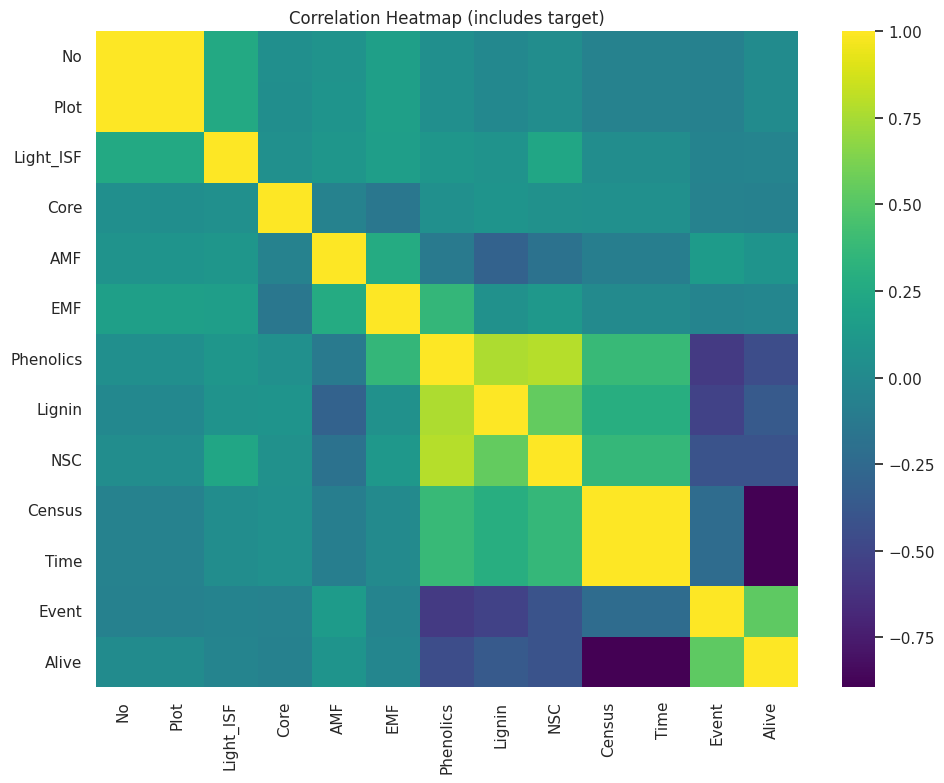

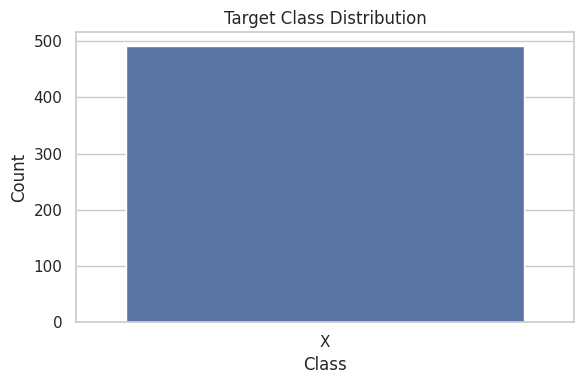

In [ ]:
#  EDA Plots
sns.set(style="whitegrid")

# Histograms
for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.histplot(X_raw[col].dropna(), kde=False)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col); plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Box Plots
for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=X_raw[col].dropna())
    plt.title(f"Box Plot: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# Density (KDE)
for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(X_raw[col].dropna(), fill=True)
    plt.title(f"Density (KDE): {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# Correlation Heatmap (include target as numeric if classification)
df_corr = df.copy()
if PROBLEM_TYPE == "classification":
    _le_tmp = LabelEncoder()
    df_corr[TARGET_COL] = _le_tmp.fit_transform(df_corr[TARGET_COL].astype(str))

corr = df_corr.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap="viridis")
plt.title("Correlation Heatmap (includes target)")
plt.tight_layout()
plt.show()

# Target imbalance bar chart (classification)
if PROBLEM_TYPE == "classification":
    plt.figure(figsize=(6,4))
    sns.countplot(x=y_raw)
    plt.title("Target Class Distribution")
    plt.xlabel("Class"); plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


Preprocessing Pipelines


 Summary Statistics (Numerical Features):
                No         Plot    Light_ISF         Core          AMF  \
count  2783.000000  2783.000000  2783.000000  2783.000000  2783.000000   
mean   3914.513834     9.561624     0.085707  2016.648940    20.553069   
std    2253.515063     5.203659     0.025638     0.477387    12.309587   
min       3.000000     1.000000     0.032000  2016.000000     0.000000   
25%    1971.000000     5.000000     0.066000  2016.000000    13.400000   
50%    3932.000000    10.000000     0.082000  2017.000000    18.000000   
75%    5879.000000    14.000000     0.100000  2017.000000    24.445000   
max    7772.000000    18.000000     0.161000  2017.000000   100.000000   

              EMF    Phenolics       Lignin          NSC       Census  \
count  1283.00000  2783.000000  2783.000000  2783.000000  2783.000000   
mean     26.47675     1.933105    15.759792    14.219641    15.282070   
std      16.63689     1.969842     6.779607     4.298271     9.166555  

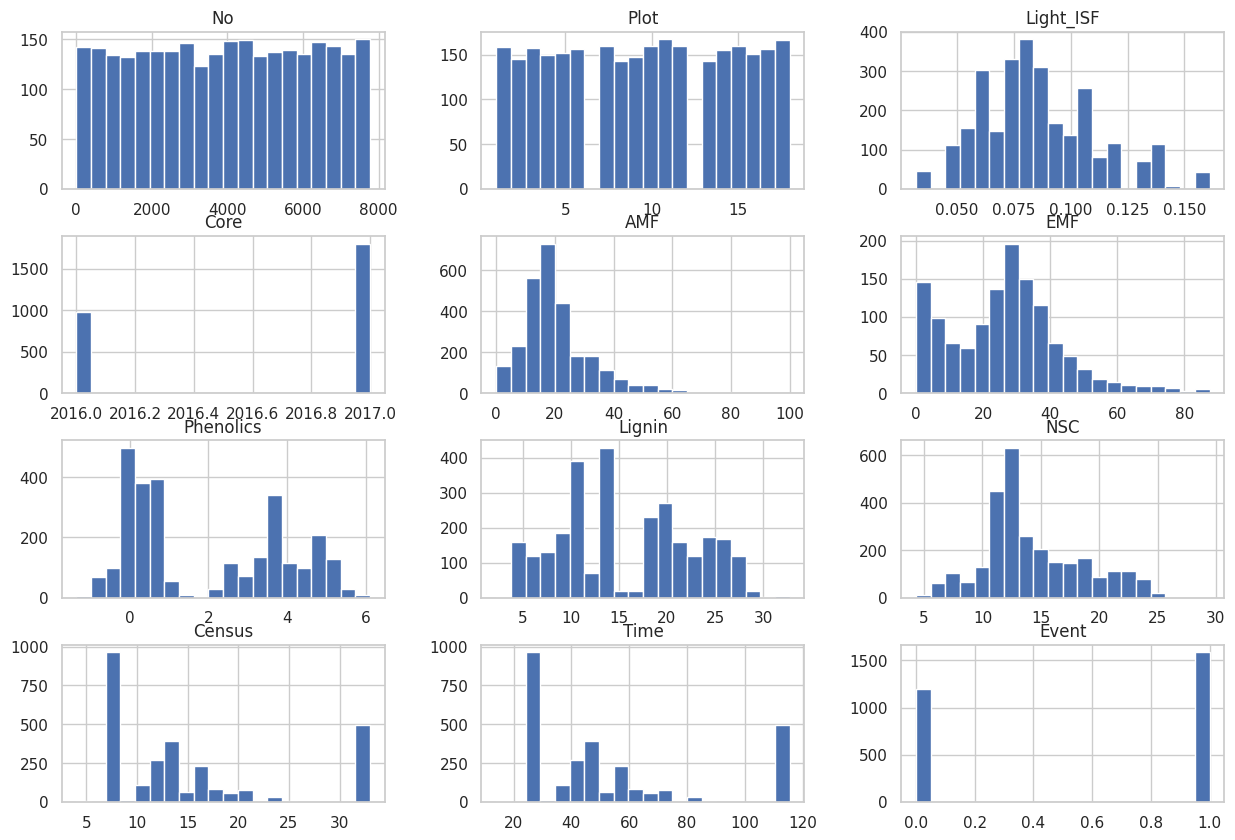

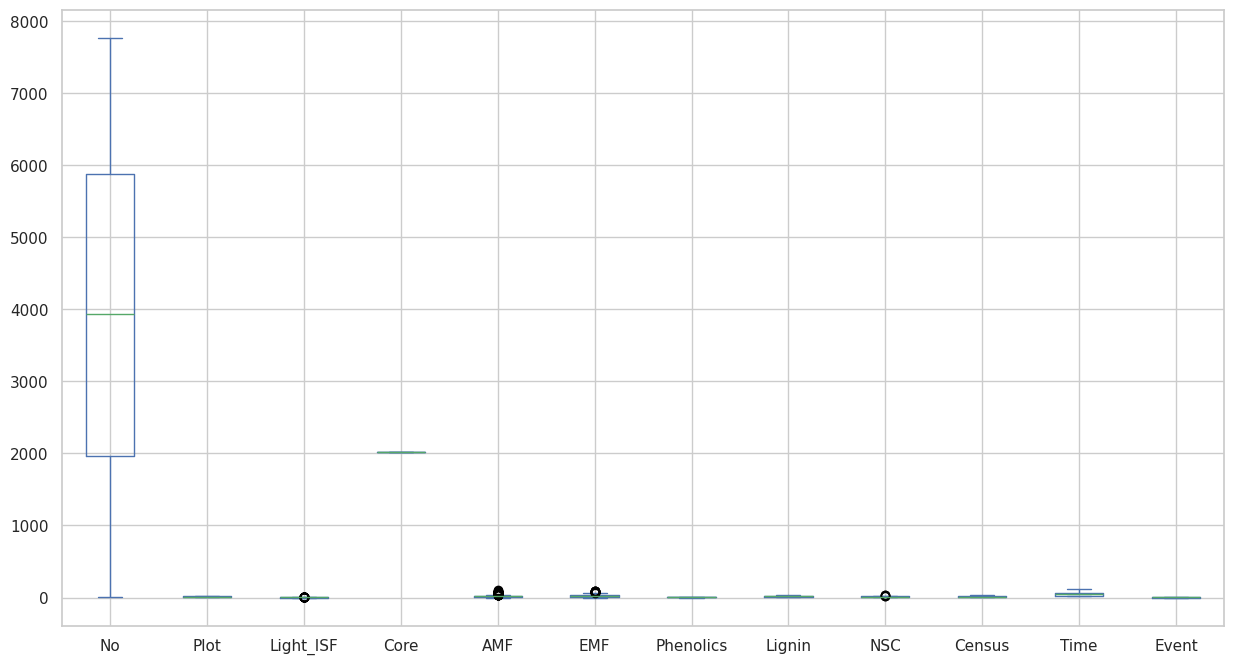

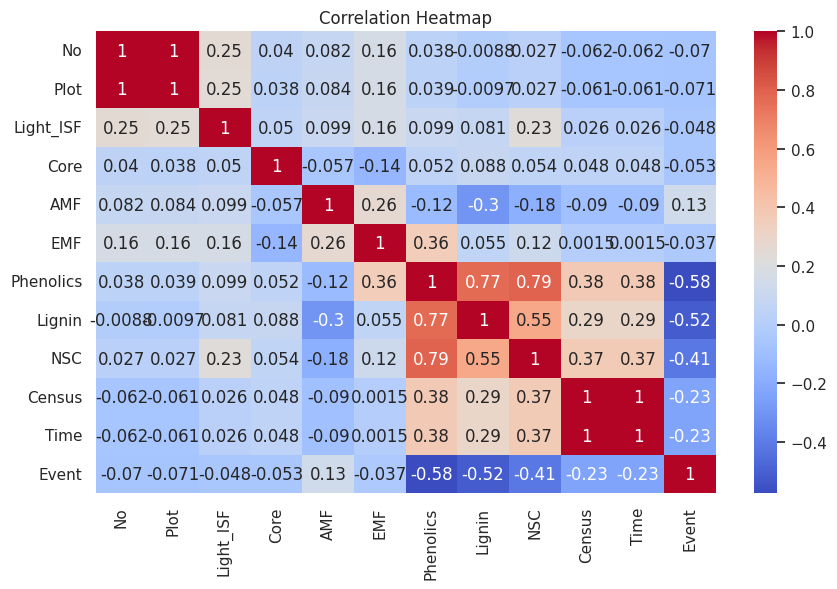

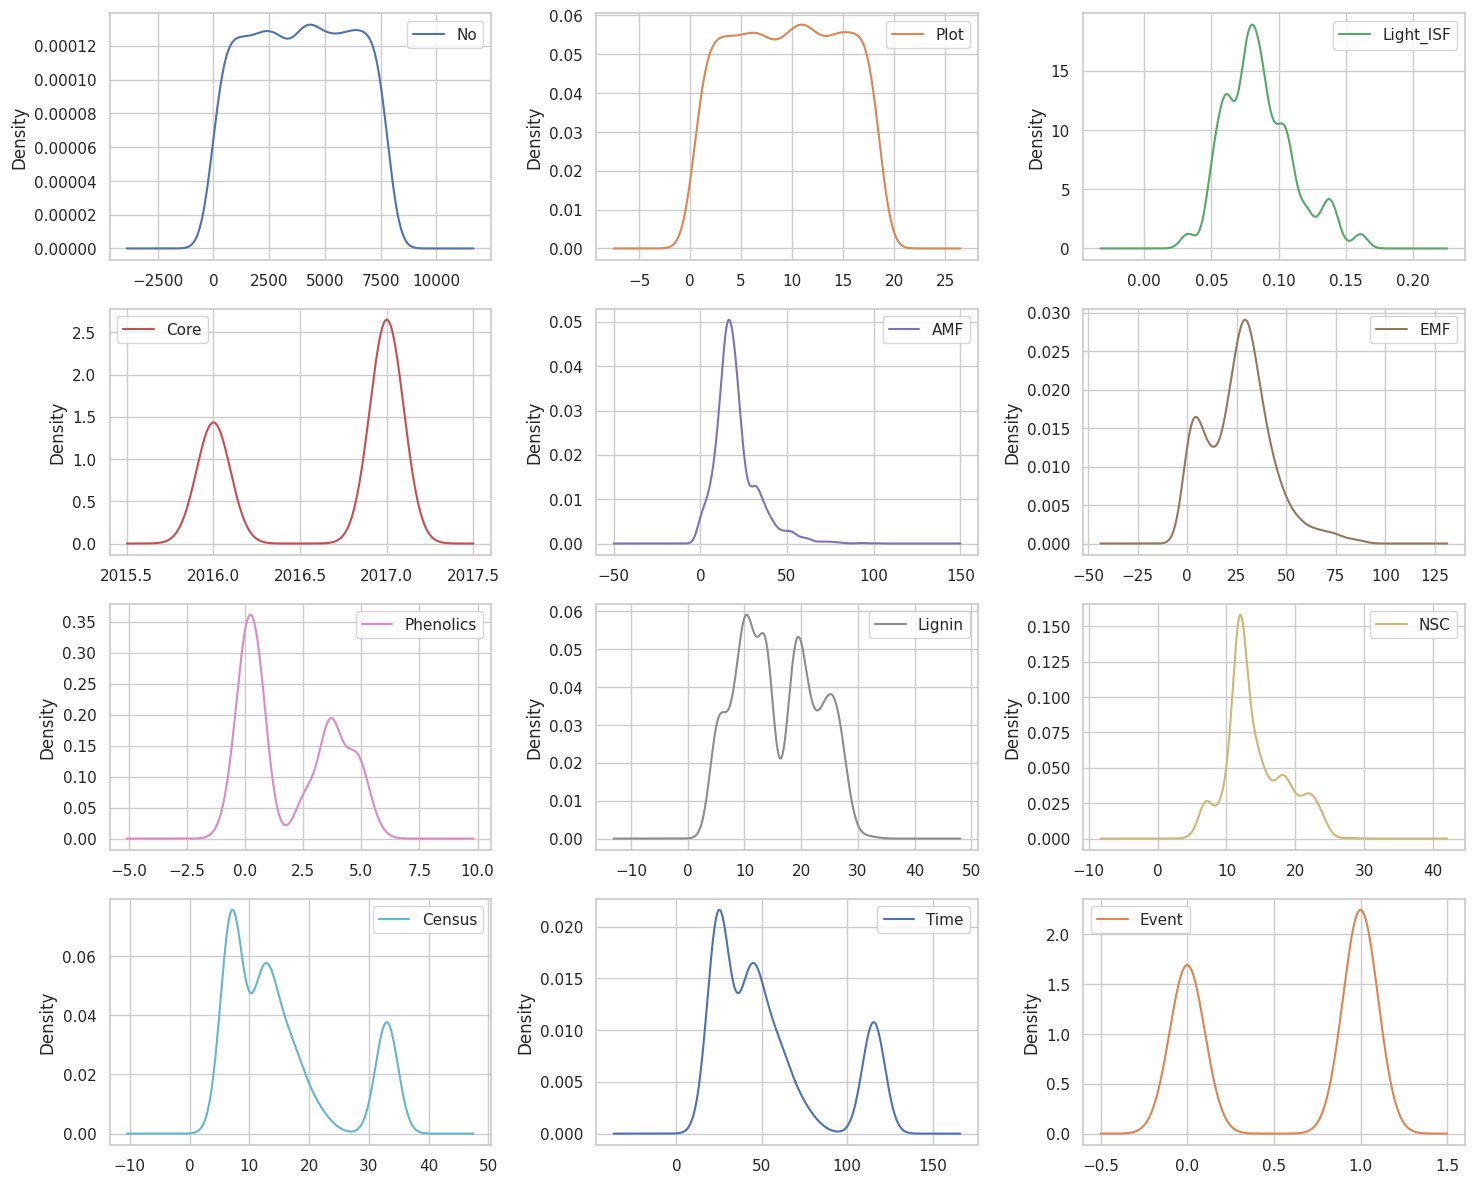

In [ ]:

# Descriptive Analysis


# Summary statistics of numerical features
print("\n Summary Statistics (Numerical Features):")
print(df.describe())

# Summary statistics of categorical features
print("\n Summary Statistics (Categorical Features):")
print(df.describe(include=['object', 'category']))

# Variance of numerical features
print("\ Variance of Numerical Features:")
print(df.var(numeric_only=True))

# Histograms of numerical features
df.hist(bins=20, figsize=(15, 10))
plt.show()

# Box plots of numerical features
df.plot(kind='box', figsize=(15, 8))
plt.show()

# Correlation Analysis
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Density plots of numerical features (12 numerical columns)
df.plot(kind='density', subplots=True, layout=(4,3), figsize=(15,12), sharex=False)
plt.tight_layout()
plt.show()


In [ ]:

# Data Preprocessing

# Encode categorical variables if any
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Separate features & target
X = df.drop("Sterile", axis=1)   # Target is 'Sterile'
y = df["Sterile"]

# Drop classes with less than 2 samples
class_counts = y.value_counts()
valid_classes = class_counts[class_counts > 1].index
mask = y.isin(valid_classes)
X = X[mask]
y = y[mask]

# Train-test split (use stratify safely now)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify numeric and categorical features again after dropping rows
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()


# Create preprocessing pipelines for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Impute missing values
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])


# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(" Data preprocessing done.")
print("Train shape:", X_train_processed.shape, " Test shape:", X_test_processed.shape)

 Data preprocessing done.
Train shape: (2226, 23)  Test shape: (557, 23)


 Helper Functions (evaluation, curves, feature names)


 Summary Statistics for Numeric Columns:
                No         Plot      Subplot      Species    Light_ISF  \
count  2783.000000  2783.000000  2783.000000  2783.000000  2783.000000   
mean   3914.513834     9.561624     1.574201     1.410349     0.085707   
std    2253.515063     5.203659     1.207517     1.104754     0.025638   
min       3.000000     1.000000     0.000000     0.000000     0.032000   
25%    1971.000000     5.000000     0.000000     0.000000     0.066000   
50%    3932.000000    10.000000     2.000000     1.000000     0.082000   
75%    5879.000000    14.000000     3.000000     2.000000     0.100000   
max    7772.000000    18.000000     4.000000     3.000000     0.161000   

         Light_Cat         Core         Soil        Adult      Sterile  ...  \
count  2783.000000  2783.000000  2783.000000  2783.000000  2783.000000  ...   
mean      1.420410  2016.648940     3.050665    18.052821     0.151994  ...   
std       0.679927     0.477387     2.002143    10.540

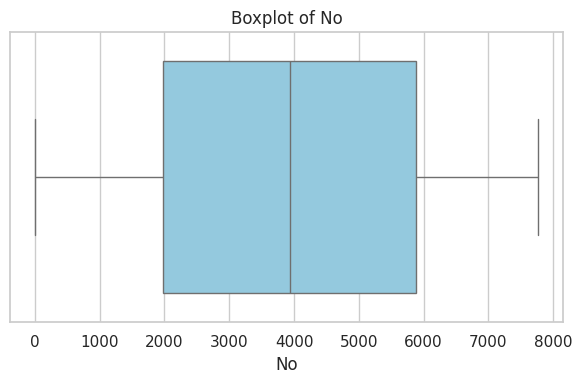

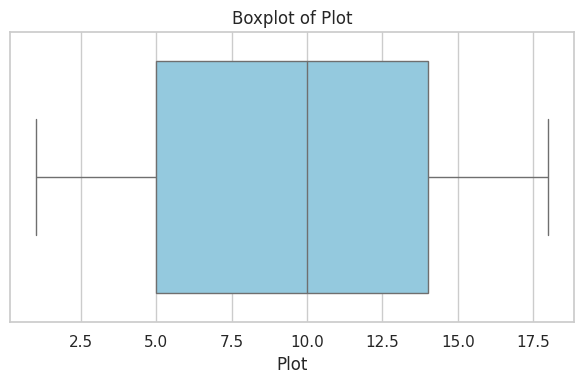

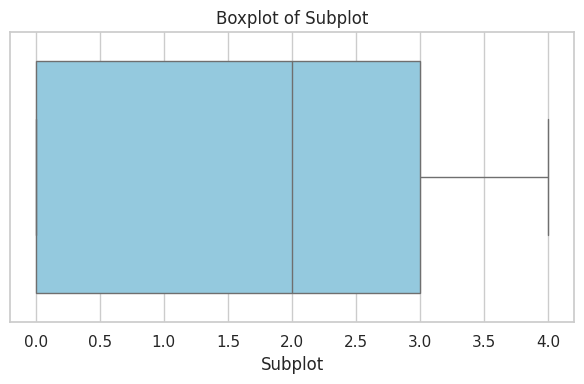

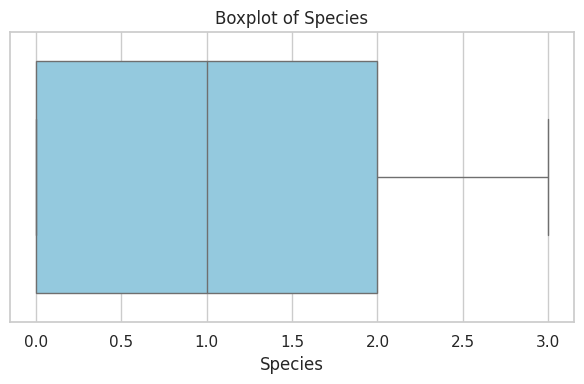

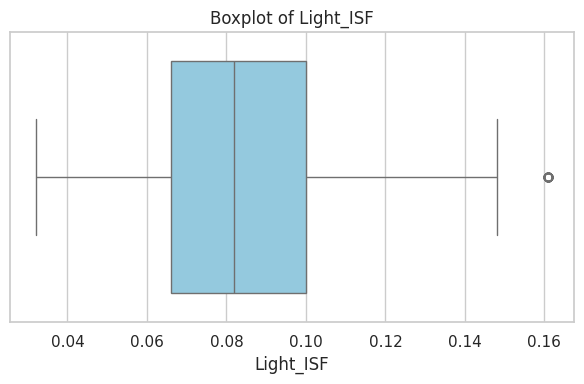

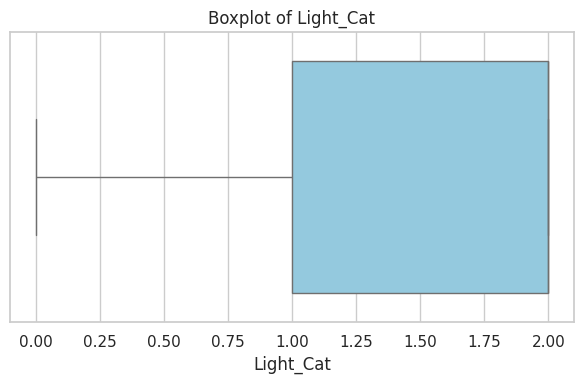

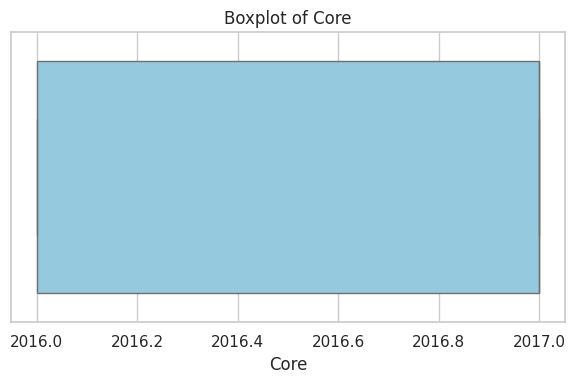

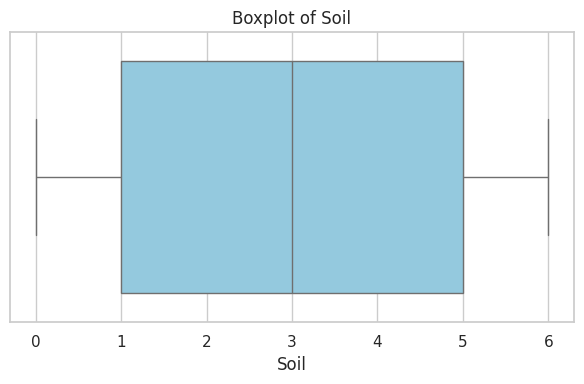

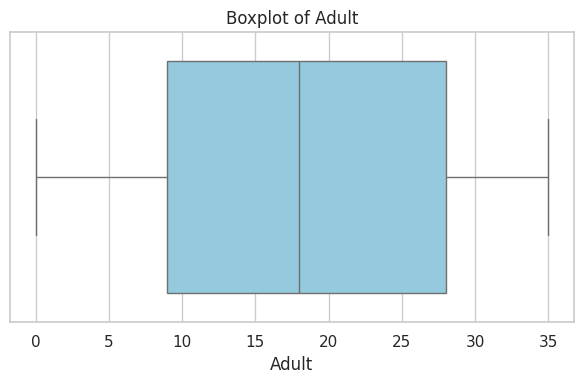

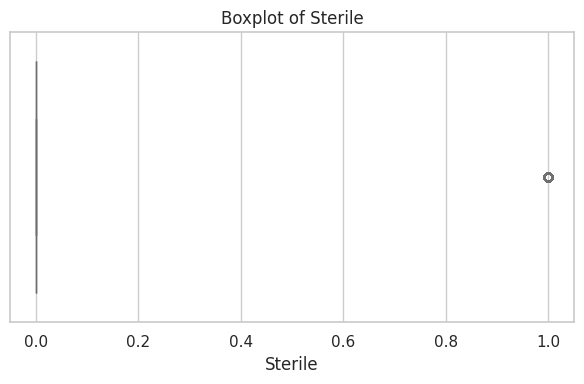

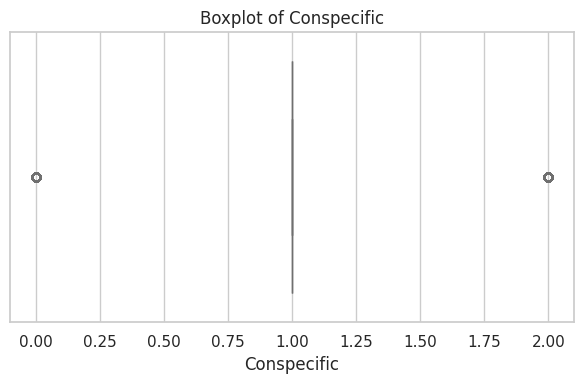

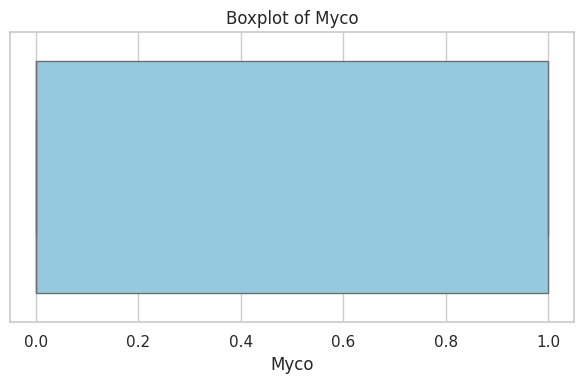

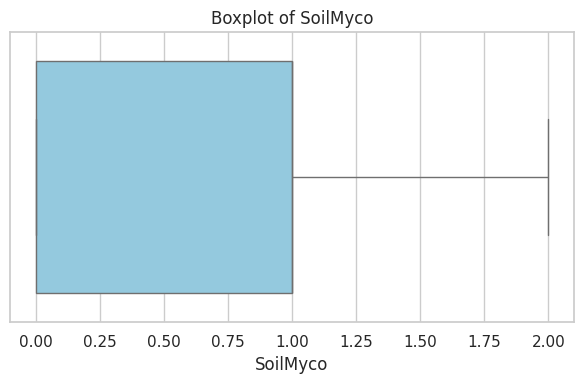

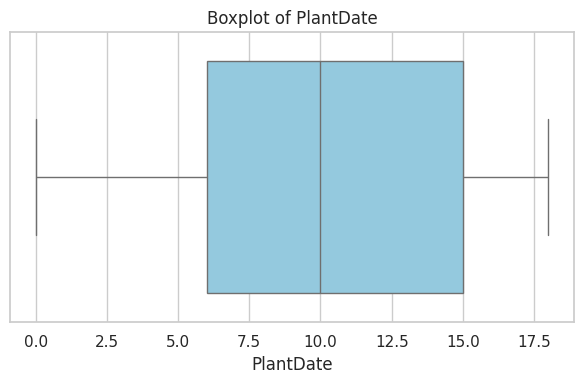

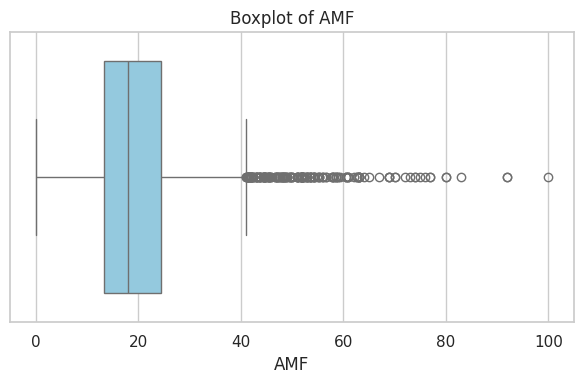

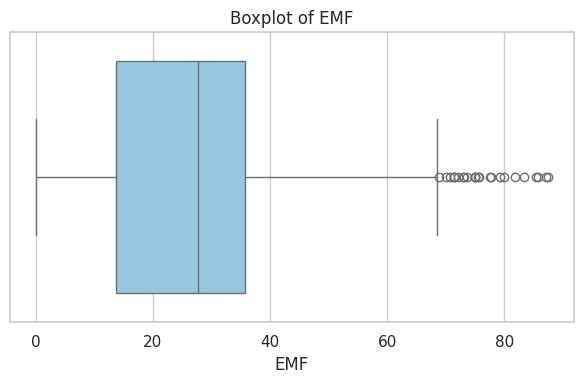

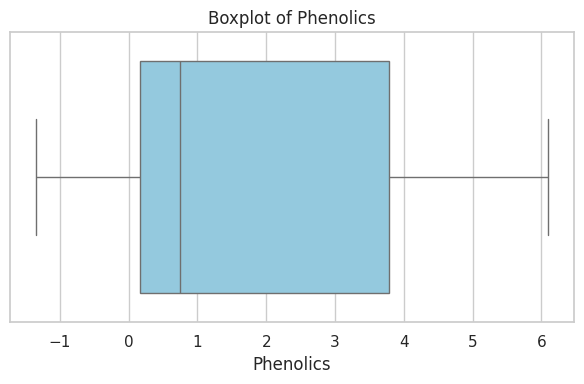

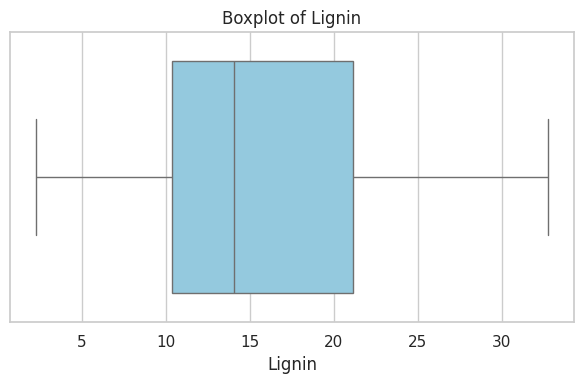

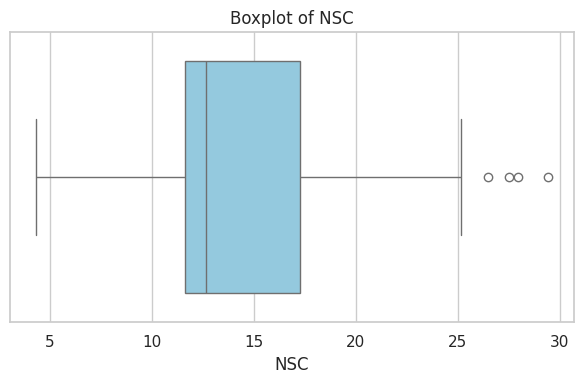

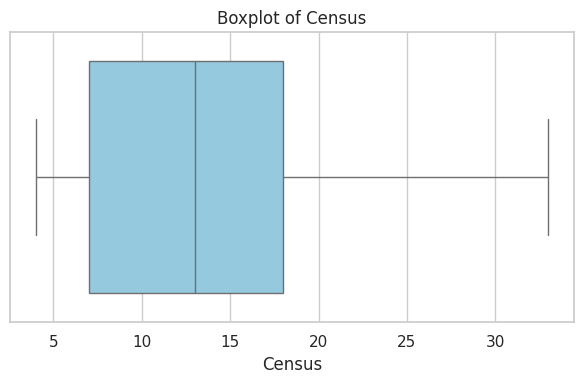

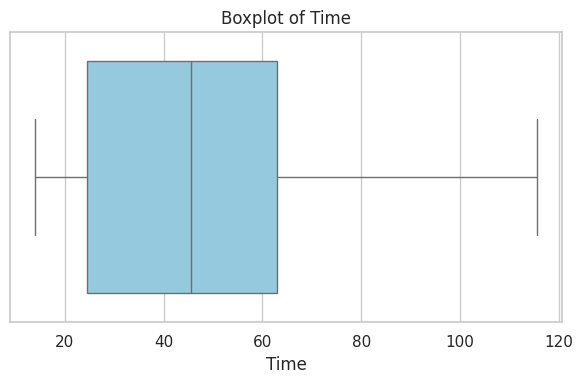

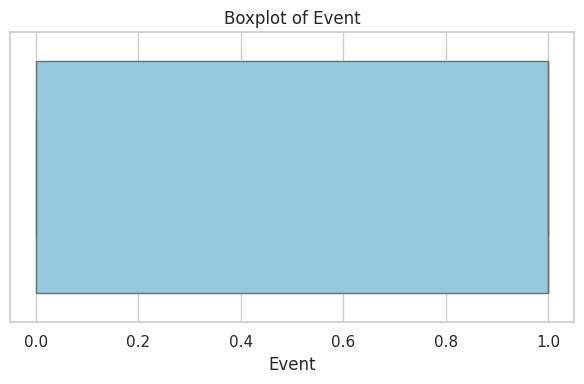

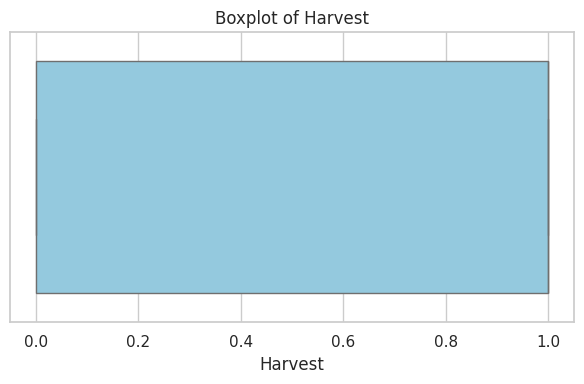

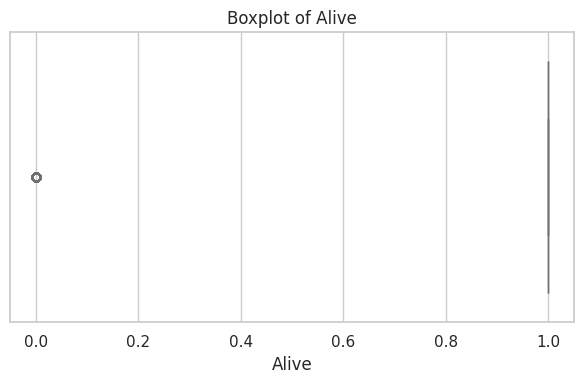

In [ ]:

#  Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import learning_curve, StratifiedKFold, KFold
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc



#  Boxplots for Numeric Columns
 # Select only numerical columns for boxplot analysis
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Show descriptive stats as a table
print("\n Summary Statistics for Numeric Columns:")
print(df[numeric_cols].describe())

# Create boxplots for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()
    plt.show()

#  Helper Function: Learning Curves

def plot_learning_curves(pipeline, X_tr, y_tr, title, scoring):
    """Plots train vs validation scores (CV) and their difference."""
    if PROBLEM_TYPE == "classification":
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    else:
        cv = KFold(n_splits=5, shuffle=True, random_state=42)

    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X_tr, y_tr, cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.2, 1.0, 6), n_jobs=None, shuffle=True, random_state=42
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    # Train vs Validation curve
    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_mean, marker='o', label='Train')
    plt.plot(train_sizes, val_mean, marker='o', label='Validation')
    plt.title(f"Learning Curve — {title}")
    plt.xlabel("Training Samples"); plt.ylabel(scoring.upper())
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Difference curve
    plt.figure(figsize=(7, 4))
    plt.plot(train_sizes, (train_mean - val_mean), marker='o')
    plt.axhline(0, linestyle="--")
    plt.title(f"Difference (Train − Validation) — {title}")
    plt.xlabel("Training Samples"); plt.ylabel(f"Δ {scoring.upper()}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


#  Regression Evaluation

def evaluate_regression(pipe, name):
    pipe.fit(X_train_processed, y_train)
    y_pred = pipe.predict(X_test_processed)

    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print(f"\n[{name}]")
    print(f"R2: {r2:.4f} | MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f}")

    # Predicted vs Actual
    plt.figure(figsize=(6, 5))
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.xlabel("Actual"); plt.ylabel("Predicted")
    plt.title(f"Predicted vs Actual — {name}")
    plt.tight_layout()
    plt.show()

    # Learning curves (R² as accuracy equivalent)
    scoring = "r2"
    plot_learning_curves(pipe, X_train_processed, y_train, name, scoring)


#  Classification Evaluation

def evaluate_classification(pipe, name):
    pipe.fit(X_train_processed, y_train)
    y_pred = pipe.predict(X_test_processed)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print(f"\n[{name}]")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print("\nClassification Report:")
    # Assuming classes_ is defined elsewhere and represents the original class labels
    # If not, you might need to retrieve them from the LabelEncoder used during preprocessing
    try:
      print(classification_report(y_test, y_pred, zero_division=0, target_names=[str(c) for c in classes_]))
    except NameError:
      print(classification_report(y_test, y_pred, zero_division=0))


    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    # plt.figure(figsize=(5,4))
    # sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    # plt.title(f"Confusion Matrix — {name}")
    # plt.xlabel("Predicted"); plt.ylabel("True")
    # plt.tight_layout()
    # plt.show()

    # ROC/AUC if possible
    model = pipe.named_steps["model"]
    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = pipe.predict_proba(X_test_processed)
    elif hasattr(model, "decision_function"):
        y_score = pipe.decision_function(X_test_processed)

    if y_score is not None:
        # Re-encode y_test to 0-based for label_binarize if it wasn't already
        y_test_encoded = LabelEncoder().fit_transform(y_test)
        n_classes = len(np.unique(y_test_encoded))

        if n_classes > 2: # Multi-class ROC
            y_true_bin = label_binarize(y_test_encoded, classes=np.arange(n_classes))

            fpr, tpr, roc_auc = {}, {}, {}
            for i in range(n_classes):
                fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
                roc_auc[i] = auc(fpr[i], tpr[i])

            # micro/macro
            fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
            roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

            all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
            mean_tpr = np.zeros_like(all_fpr)
            for i in range(n_classes):
                mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
            mean_tpr /= n_classes
            fpr["macro"] = all_fpr
            tpr["macro"] = mean_tpr
            roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

            # plt.figure(figsize=(7,5))
            # plt.plot(fpr["micro"], tpr["micro"], label=f"micro AUC={roc_auc['micro']:.3f}")
            # plt.plot(fpr["macro"], tpr["macro"], label=f"macro AUC={roc_auc['macro']:.3f}")
            # for i in range(n_classes):
            #     plt.plot(fpr[i], tpr[i], label=f"class {i} AUC={roc_auc[i]:.3f}")
            # plt.plot([0,1],[0,1],'--')
            # plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"ROC — {name}")
            # plt.legend(); plt.tight_layout()
            # plt.show()
        elif n_classes == 2: # Binary ROC
            fpr, tpr, _ = roc_curve(y_test_encoded, y_score[:, 1])
            roc_auc = auc(fpr, tpr)
            # plt.figure(figsize=(7,5))
            # plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
            # plt.plot([0,1],[0,1],'--')
            # plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"ROC — {name}")
            # plt.legend(); plt.tight_layout()
            # plt.show()


    # Learning curves (Train vs Validation + Difference)
    scoring = "accuracy"
    plot_learning_curves(pipe, X_train_processed, y_train, name, scoring)



#  Get Feature Names after Transform

def get_transformed_feature_names(fitted_preprocessor, numeric_features, categorical_features):
    """Get feature names after ColumnTransformer for plotting the tree."""
    feat_names = []
    # numeric
    feat_names.extend(numeric_features)
    # categorical one-hot expanded
    try:
        ohe = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
        cat_names = ohe.get_feature_names_out(categorical_features).tolist()
    except Exception:
        # fallback: generic names
        cat_names = []
        for c in categorical_features:
            cat_names += [f"{c}__{i}" for i in range(1, 1 + len(pd.unique(X_raw[c].astype(str))))]
    feat_names.extend(cat_names)
    return feat_names

Model 1 :Neural Network


Epoch 1/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6518 - loss: 0.6238 - val_accuracy: 0.9982 - val_loss: 0.0333
Epoch 2/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9966 - loss: 0.0382 - val_accuracy: 1.0000 - val_loss: 0.0041
Epoch 3/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9968 - loss: 0.0146 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 4/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 5.3839e-04
Epoch 5/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 3.9183e-04
Epoch 6/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 1.8747e-04
Epoch 7/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 1.0000 - val_loss: 1.3230e-04
Epoch 8/30
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0010 - 

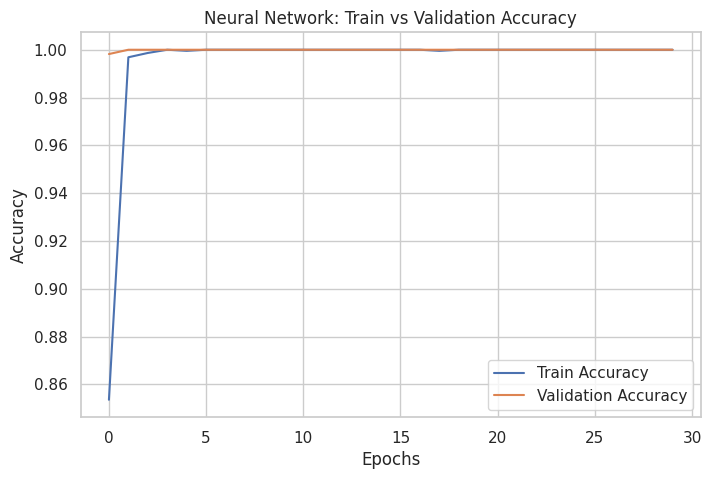

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

 Neural Network Evaluation:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0

Confusion Matrix:



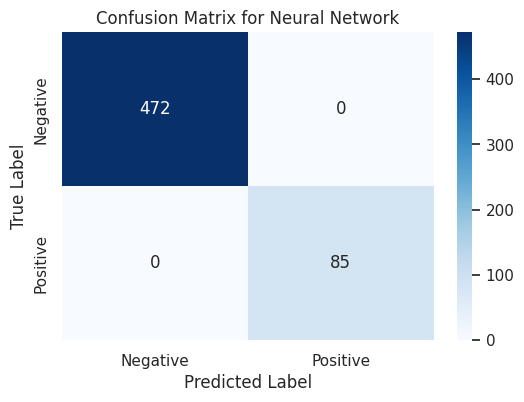


=== Plotting ROC Curve ===


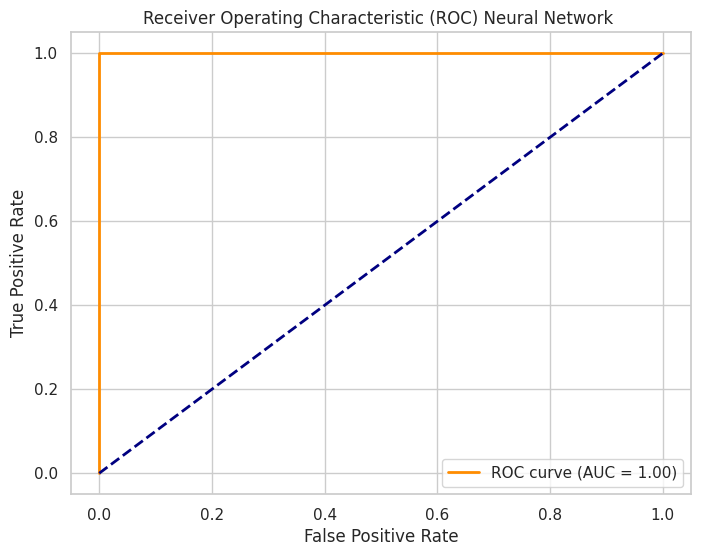

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Re-encode y_train and y_test so they start from 0
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# One-hot encode
num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# Neural Network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_processed, y_train_cat,
                    validation_data=(X_test_processed, y_test_cat),
                    epochs=30, batch_size=16, verbose=1)

# Plot training vs validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Neural Network: Train vs Validation Accuracy")
plt.show()


# Evaluation
y_pred_nn = model.predict(X_test_processed)
y_pred_nn_classes = np.argmax(y_pred_nn, axis=1)

print("\n Neural Network Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred_nn_classes))
print("Precision:", precision_score(y_test, y_pred_nn_classes, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_nn_classes, average='weighted', zero_division=0))
print("F1-Score:", f1_score(y_test, y_pred_nn_classes, average='weighted', zero_division=0))
print("\nConfusion Matrix:\n")

cm = confusion_matrix(y_test, y_pred_nn_classes)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Neural Network')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_pred_nn_classes.ravel())
auc_score = auc(fpr, tpr)

print("\n=== Plotting ROC Curve ===")
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Neural Network ')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Decision Tree


 Decision Tree Evaluation:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0

Confusion Matrix:


Confusion Matrix:
 [[472   0]
 [  0  85]]


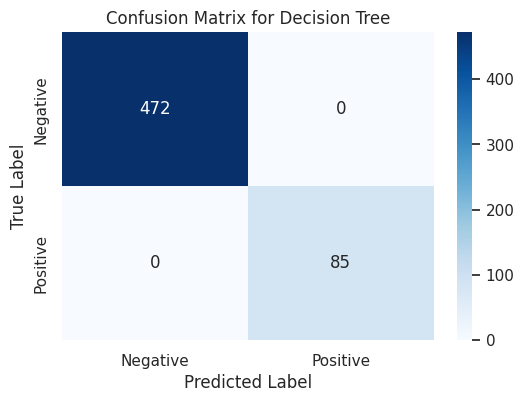

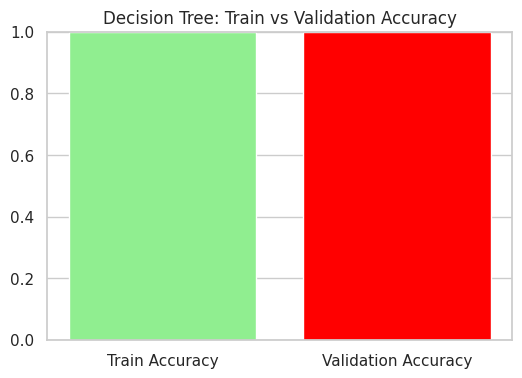


=== Plotting ROC Curve ===


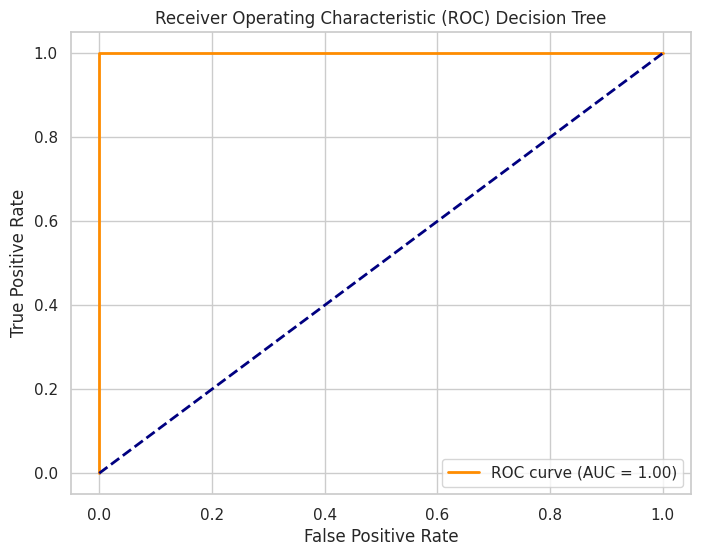

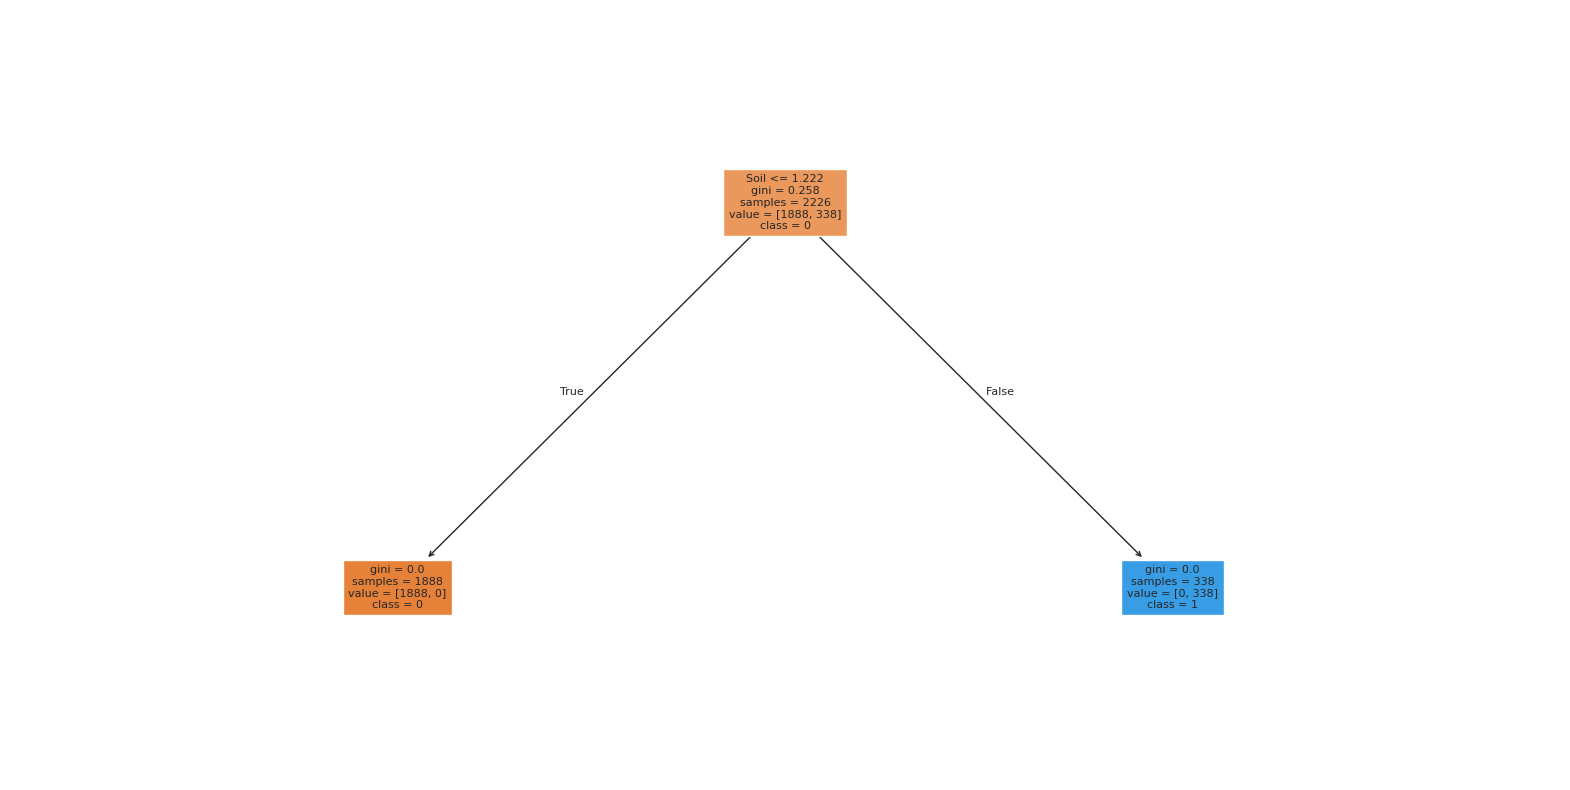

In [ ]:

# Decision Tree

from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_processed, y_train)

train_acc_dt = dt.score(X_train_processed, y_train)
val_acc_dt = dt.score(X_test_processed, y_test)


print("\n Decision Tree Evaluation:")
y_pred_dt = dt.predict(X_test_processed)
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dt, average='weighted', zero_division=0))
print("F1-Score:", f1_score(y_test, y_pred_dt, average='weighted', zero_division=0))

print("\nConfusion Matrix:\n")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Decision Tree')
plt.show()

plt.figure(figsize=(6,4))
plt.bar(["Train Accuracy", "Validation Accuracy"], [train_acc_dt, val_acc_dt], color=['lightgreen','red'])
plt.title("Decision Tree: Train vs Validation Accuracy")
plt.ylim(0,1)
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_pred_dt.ravel())
auc_score = auc(fpr, tpr)

print("\n=== Plotting ROC Curve ===")
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Decision Tree')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Visualize Decision Tree
# Need to get feature names after preprocessing
transformed_feature_names = get_transformed_feature_names(preprocessor.fit(X_train), numeric_features, categorical_features)

plt.figure(figsize=(20,10))
plot_tree(dt, filled=True, feature_names=transformed_feature_names, class_names=[str(c) for c in np.unique(y)], fontsize=8)
plt.show()

K-Nearest Neighbors (KNN)

\ KNN Evaluation:
Accuracy: 0.9982046678635548
Precision: 0.9982084634917503
Recall: 0.9982046678635548
F1-Score: 0.9982003061411983

Confusion Matrix:



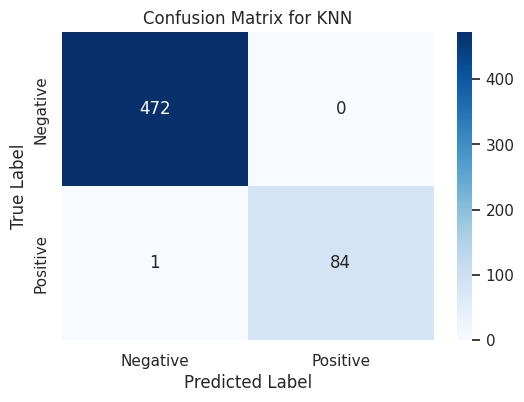

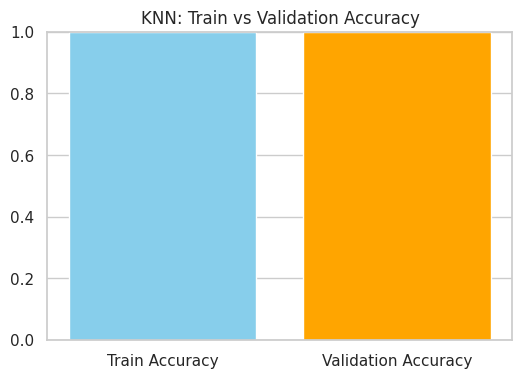


=== Plotting ROC Curve ===


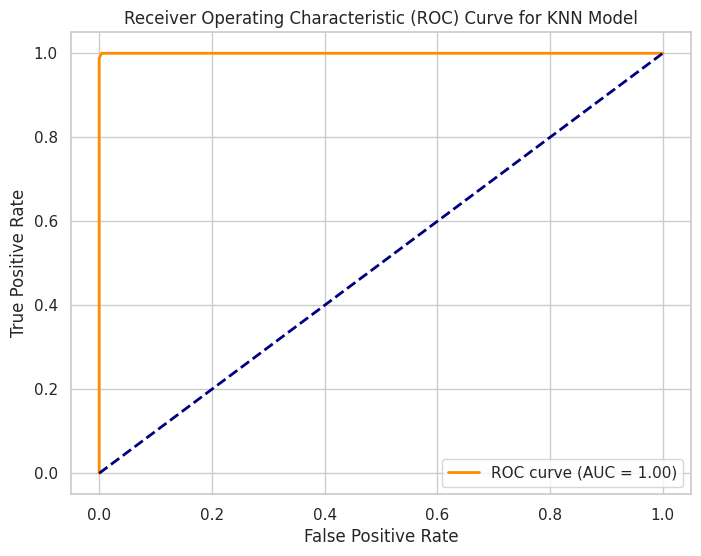


[KNN]
Accuracy: 0.9982 | Precision: 0.9982 | Recall: 0.9982 | F1: 0.9982

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       472
           1       1.00      0.99      0.99        85

    accuracy                           1.00       557
   macro avg       1.00      0.99      1.00       557
weighted avg       1.00      1.00      1.00       557



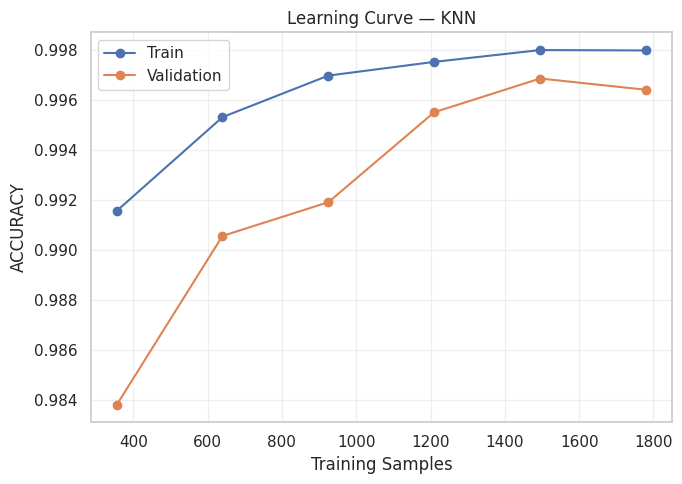

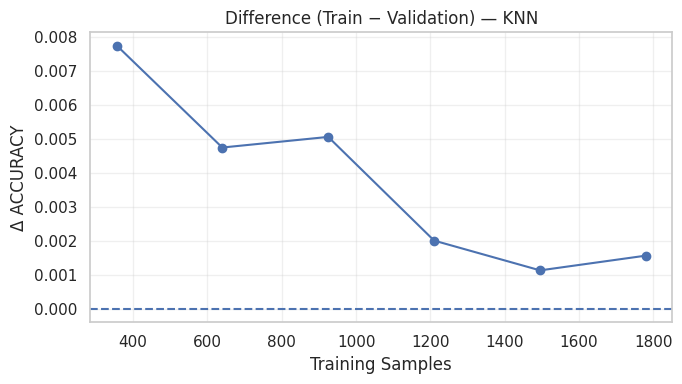

In [ ]:

# K-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_processed, y_train)

train_acc_knn = knn.score(X_train_processed, y_train)
val_acc_knn = knn.score(X_test_processed, y_test)

print("\ KNN Evaluation:")
y_pred_knn = knn.predict(X_test_processed)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_knn, average='weighted', zero_division=0))
print("F1-Score:", f1_score(y_test, y_pred_knn, average='weighted', zero_division=0))

cm = confusion_matrix(y_test, y_pred_knn)
print("\nConfusion Matrix:\n")
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for KNN')
plt.show()

# Plot bar for train vs validation accuracy
plt.figure(figsize=(6,4))
plt.bar(["Train Accuracy", "Validation Accuracy"], [train_acc_knn, val_acc_knn], color=['skyblue','orange'])
plt.title("KNN: Train vs Validation Accuracy")
plt.ylim(0,1)
plt.show()

# Plot ROC Curve
y_prob_knn = knn.predict_proba(X_test_processed)[:, 1] # Probability of the positive class
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)
auc_score = auc(fpr, tpr)

print("\n=== Plotting ROC Curve ===")
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for KNN Model')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Plot learning curves
evaluate_classification(Pipeline([('model', knn)]), "KNN")